<a href="https://colab.research.google.com/github/franciscotovar/wtd/blob/main/Workshop3_From%20Idea%20to%20Measurement/Week7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**WEARABLE TECH DEVICES MIET2572**

IMPORTANT

Before starting:

Click File → Save a copy in Drive

Work ONLY on your copy

Do NOT edit the original notebook

Plotting two signals to compare metrics in different attempts

**SIGNAL 1**

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import find_peaks

from google.colab import files
uploaded = files.upload()
filename = list(uploaded.keys())[0]

data = pd.read_csv(filename)

print(data.columns)  # for debugging
# Adapt automatically (simple version)
t  = data.iloc[:,0].values
ax = data.iloc[:,1].values
ay = data.iloc[:,2].values
az = data.iloc[:,3].values

acc_mag = np.sqrt(ax**2 + ay**2 + az**2)

fs = 1 / np.mean(np.diff(t))  # estimate sampling rate

Saving data.csv to data (1).csv
Index(['Time (s)', 'Linear Acceleration x (m/s^2)',
       'Linear Acceleration y (m/s^2)', 'Linear Acceleration z (m/s^2)',
       'Absolute acceleration (m/s^2)'],
      dtype='object')


**SIGNAL 2**

In [4]:
from google.colab import files
uploaded = files.upload()
filename = list(uploaded.keys())[0]

data2 = pd.read_csv(filename)

print(data2.columns)  # for debugging
# Adapt automatically (simple version)
t2  = data2.iloc[:,0].values
ax2 = data2.iloc[:,1].values
ay2 = data2.iloc[:,2].values
az2 = data2.iloc[:,3].values

acc_mag2 = np.sqrt(ax2**2 + ay2**2 + az2**2)

fs2 = 1 / np.mean(np.diff(t2))  # estimate sampling rate

Saving Raw Data.csv to Raw Data (2).csv
Index(['Time (s)', 'Linear Acceleration x (m/s^2)',
       'Linear Acceleration y (m/s^2)', 'Linear Acceleration z (m/s^2)',
       'Absolute acceleration (m/s^2)'],
      dtype='object')


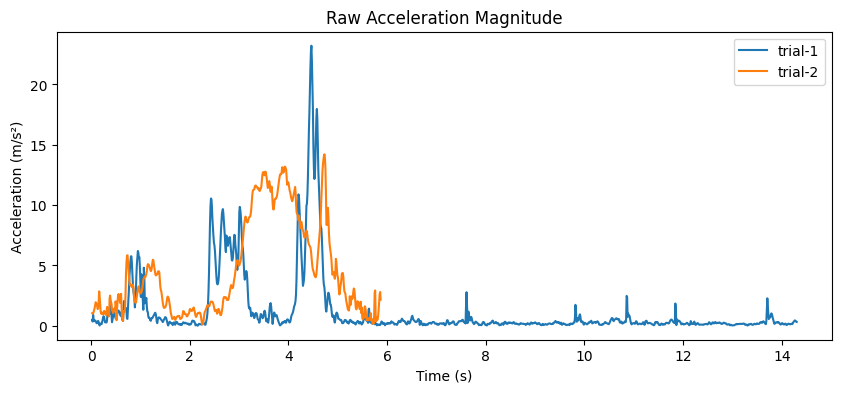

In [13]:
plt.figure(figsize=(10,4))
plt.plot(t, acc_mag, label="trial-1")
plt.plot(t2, acc_mag2, label="trial-2")

plt.title("Raw Acceleration Magnitude")
plt.xlabel("Time (s)")
plt.ylabel("Acceleration (m/s²)")
plt.legend()
plt.show()

*Smoothing* (with Moving Average)

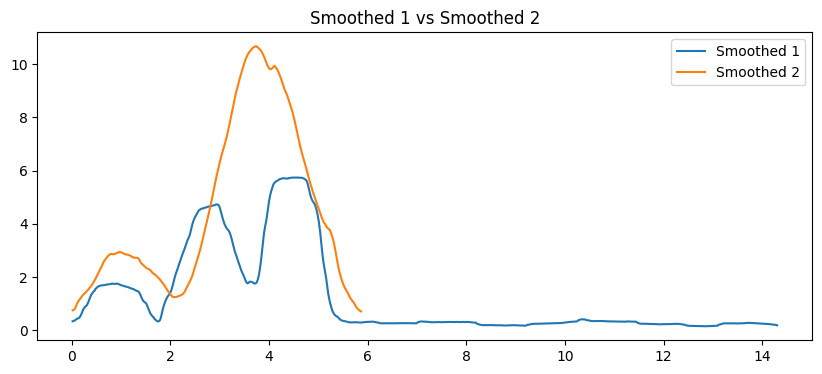

In [34]:
window_size = int(1.2 * fs)  # 100 ms window
acc_smooth = np.convolve(acc_mag,
                         np.ones(window_size)/window_size,
                         mode='same')

window_size2 = int(1.3 * fs2)  # 100 ms window
acc_smooth2 = np.convolve(acc_mag2,
                         np.ones(window_size2)/window_size2,
                         mode='same')

plt.figure(figsize=(10,4))
plt.plot(t, acc_smooth, label="Smoothed 1")
plt.plot(t2, acc_smooth2, label="Smoothed 2")
plt.legend()
plt.title("Smoothed 1 vs Smoothed 2")
plt.show()

Visualize events

Detected events signal 1: 2
Threshold 1= 1.83 m/s^2
Detected Events signal 2: 1
Threshold 2= 5.10 m/s^2
Minimum time between events = 0.4 s


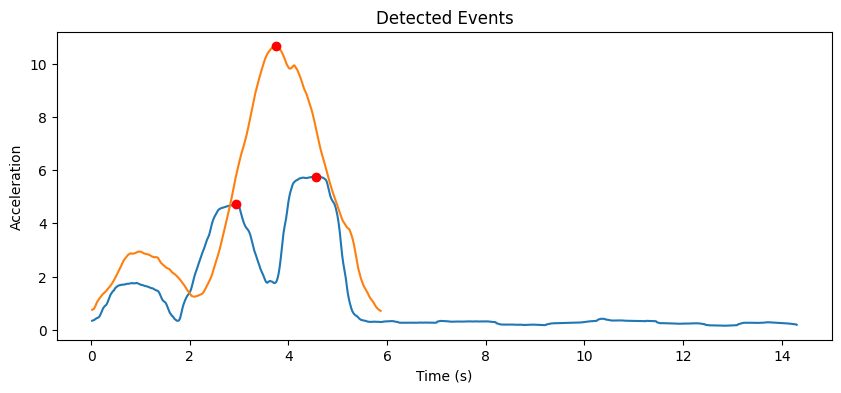

In [50]:
# ===== MODEL PARAMETERS =====
alpha = 0.6          # amplitude offset above baseline
delta_t_min = 0.4      # minimum time between steps (seconds) # 400 ms physiological constraint

#signal 1
threshold = np.mean(acc_smooth) + alpha
min_distance = int(delta_t_min * fs)


peaks, _ = find_peaks(acc_smooth,
                      height=threshold,
                      distance=min_distance)



#signal 2
threshold2 = np.mean(acc_smooth2) + alpha
min_distance2 = int(delta_t_min * fs2)
peaks2, _ = find_peaks(acc_smooth2,
                      height=threshold2,
                      distance=min_distance2)

step_count = len(peaks)
print("Detected events signal 1:", step_count)
print(f"Threshold 1= {threshold:.2f} m/s^2")

step_count2 = len(peaks2)
print("Detected Events signal 2:", step_count2)
print(f"Threshold 2= {threshold2:.2f} m/s^2")
print(f"Minimum time between events = {delta_t_min} s")

plt.figure(figsize=(10,4))
plt.plot(t, acc_smooth)
plt.plot(t[peaks], acc_smooth[peaks], "ro")

plt.plot(t2, acc_smooth2)
plt.plot(t2[peaks2], acc_smooth2[peaks2], "ro")
plt.title("Detected Events")
plt.xlabel("Time (s)")
plt.ylabel("Acceleration")
plt.show()

RMS  (Root Mean Square)

•	measures the average magnitude of the signal

•	always positive

•	captures intensity, not events

•	signal with large peaks → high RMS

•	smooth signal → low RMS


RMS signal 1: 2.05 m/s²
RMS signal 1: 5.52 m/s²


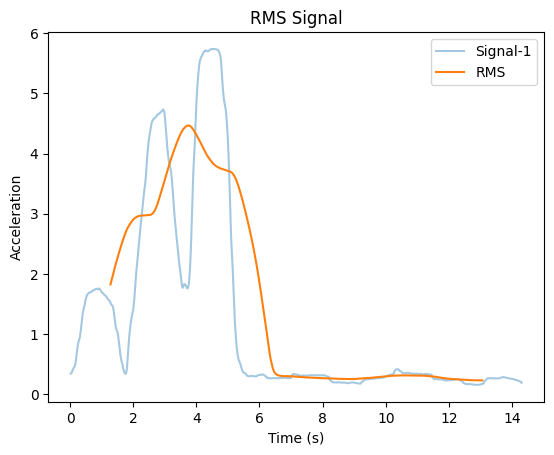

In [70]:
import numpy as np

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# RMS global
rms = np.sqrt(np.mean(acc_smooth**2))
print(f"RMS signal 1: {rms:.2f} m/s²") ## f  -> floating-point decimal format # .2 display 3 digits after the decimal point

rms2 = np.sqrt(np.mean(acc_smooth2**2))
print(f"RMS signal 1: {rms2:.2f} m/s²")


# RMS in a selected window
window = 250  # samples
rms_signal1 = np.sqrt(pd.Series(acc_smooth**2).rolling(window, center=True).mean())


# Plot
plt.plot(t, acc_smooth, alpha=0.4, label='Signal-1')
plt.plot(t, rms_signal1, label='RMS')
plt.xlabel('Time (s)')
plt.ylabel('Acceleration')
plt.title('RMS Signal')
plt.legend()
plt.show()

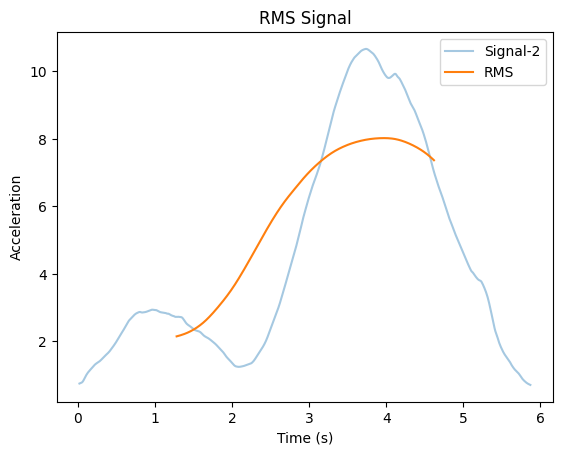

In [59]:
rms_signal2 = np.sqrt(pd.Series(acc_smooth2**2).rolling(window, center=True).mean())
# Plot
plt.plot(t2, acc_smooth2, alpha=0.4, label='Signal-2')
plt.plot(t2, rms_signal2, label='RMS')
plt.xlabel('Time (s)')
plt.ylabel('Acceleration')
plt.title('RMS Signal')
plt.legend()
plt.show()

**STD (variability).  How much the acceleration fluctuates.**


• measures how spread out the signal is

STD can be computed:
- within a signal (variability over time)
- across trials (consistency of a metric)

For across trials:
- compute a metric per trial (e.g. RMS or peak)
- store values in a list
- compute STD of that *list*

# **Calculation within a signal**




In [74]:
std_signal1 = np.std(acc_smooth)
print(f"RMS signal 1: {std_signal1:.3f} m/s²") ## f  -> floating-point decimal format # .3 display 3 digits after the decimal point

std_signal2 = np.std(acc_smooth2)
print(f"RMS signal 2: {std_signal2:.3f} m/s²") ## f  -> floating-point decimal format # .3 display 3 digits after the decimal point


RMS signal 1: 1.642 m/s²
RMS signal 2: 3.203 m/s²


# **Calculation within across trials**


values = [std_signal1, std_signal2]

std_trials = np.std(values)

print(std_trials)

In [81]:
values = [std_signal1,std_signal2]
std_trials = np.std(values)
print(f"STD - fluctuation of acceleration across signal 1 and signal 2: {std_trials:.3f} m/s²")

STD - fluctuation of acceleration across signal 1 and signal 2: 0.781 m/s²
